# Session 2 — Plot Types & Choosing the Right Chart

Runnable code from the **Build It**, **Experiment**, and **Mini Project** sections.
Run each cell top to bottom.

## 1. Build It — Core Code

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)

### 2.1 Relationships — `scatter`

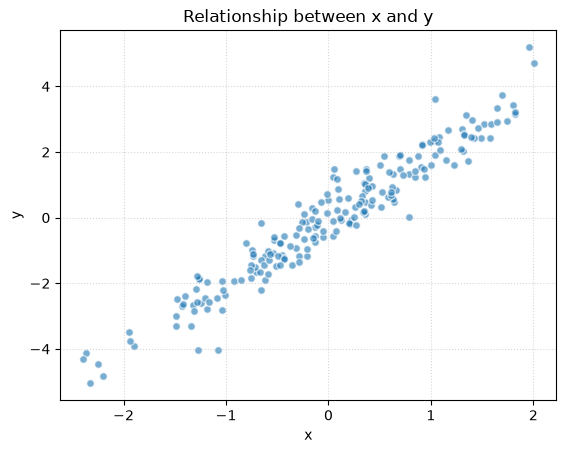

In [2]:
x = rng.normal(size=200)
y = 2 * x + rng.normal(scale=0.5, size=200)

fig, ax = plt.subplots()
ax.scatter(x, y, s=30, c="tab:blue", alpha=0.6, edgecolors="white")
ax.set_title("Relationship between x and y")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, linestyle=":", alpha=0.5)
plt.show()

### 2.2 Comparison — `bar` and `barh`

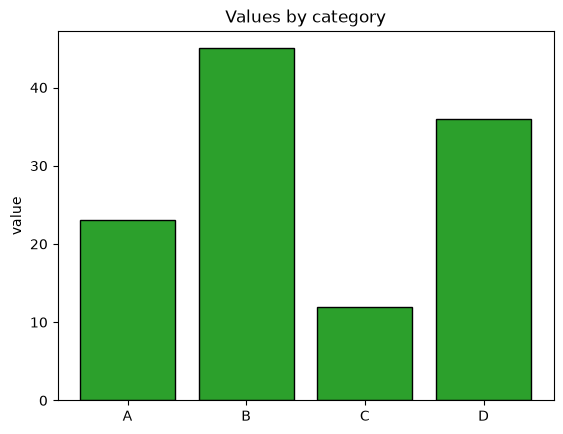

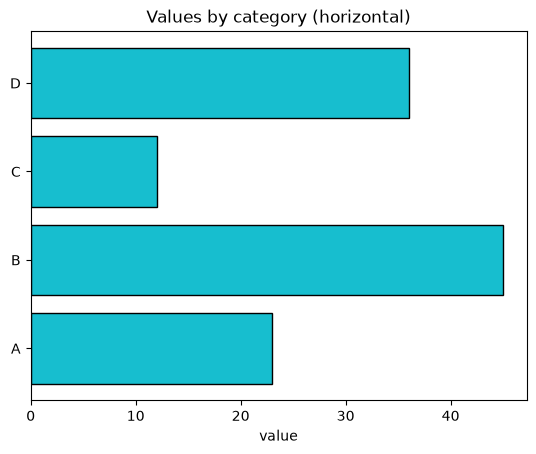

In [3]:
categories = ["A", "B", "C", "D"]
values = [23, 45, 12, 36]

fig, ax = plt.subplots()
ax.bar(categories, values, color="tab:green", edgecolor="black")
ax.set_title("Values by category")
ax.set_ylabel("value")
plt.show()

fig, ax = plt.subplots()
ax.barh(categories, values, color="tab:cyan", edgecolor="black")
ax.set_title("Values by category (horizontal)")
ax.set_xlabel("value")
plt.show()

### 2.3 Distribution — `hist` and `boxplot`

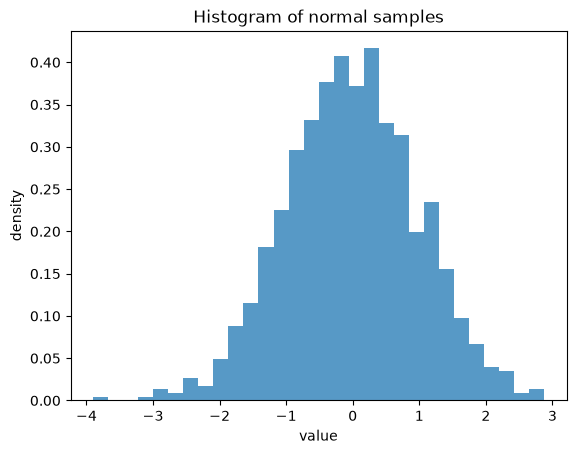

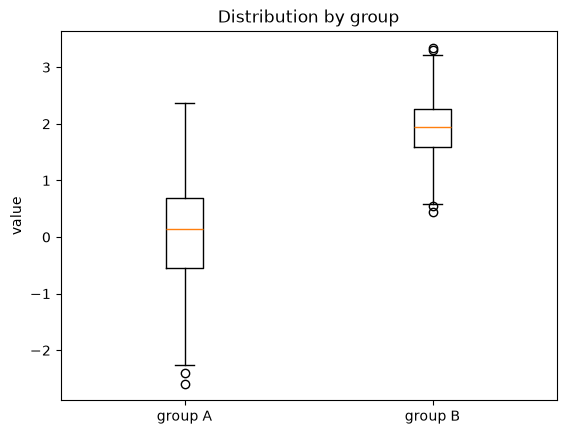

In [4]:
samples = rng.normal(loc=0, scale=1, size=1000)

fig, ax = plt.subplots()
ax.hist(samples, bins=30, density=True, color="tab:blue", alpha=0.75)
ax.set_title("Histogram of normal samples")
ax.set_xlabel("value")
ax.set_ylabel("density")
plt.show()

data = [rng.normal(0, 1, 200), rng.normal(2, 0.5, 200)]

fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=["group A", "group B"])
ax.set_title("Distribution by group")
ax.set_ylabel("value")
plt.show()

### 2.4 Composition — `pie`

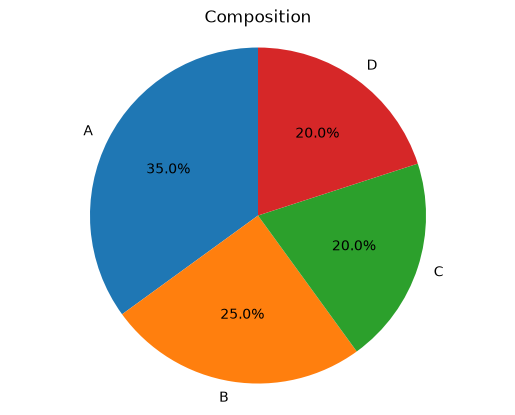

In [5]:
sizes = [35, 25, 20, 20]
labels = ["A", "B", "C", "D"]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
ax.set_title("Composition")
ax.axis("equal")
plt.show()

### 2.5 Uncertainty — `errorbar`

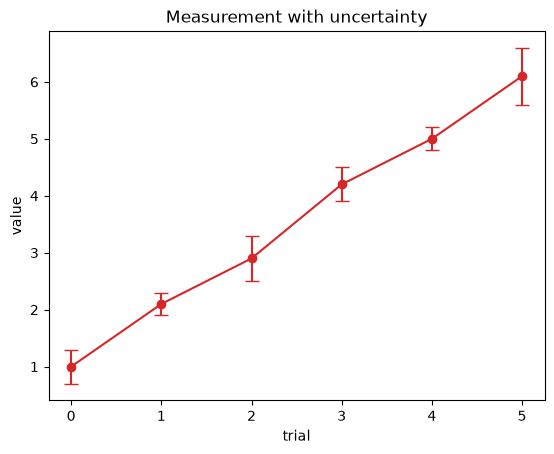

In [6]:
x = np.arange(6)
y = np.array([1.0, 2.1, 2.9, 4.2, 5.0, 6.1])
yerr = np.array([0.3, 0.2, 0.4, 0.3, 0.2, 0.5])

fig, ax = plt.subplots()
ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=5, color="tab:red")
ax.set_title("Measurement with uncertainty")
ax.set_xlabel("trial")
ax.set_ylabel("value")
plt.show()

### 2.6 Range and shape — `fill_between` and `stem`

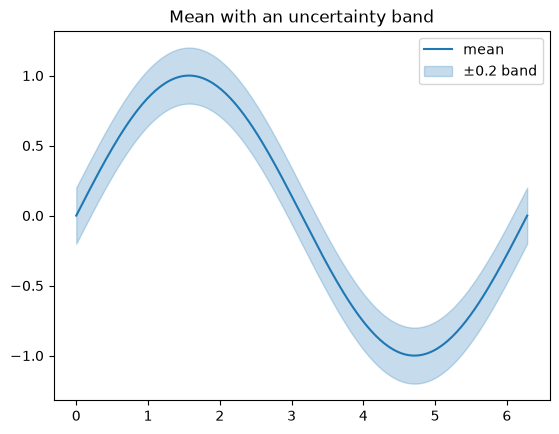

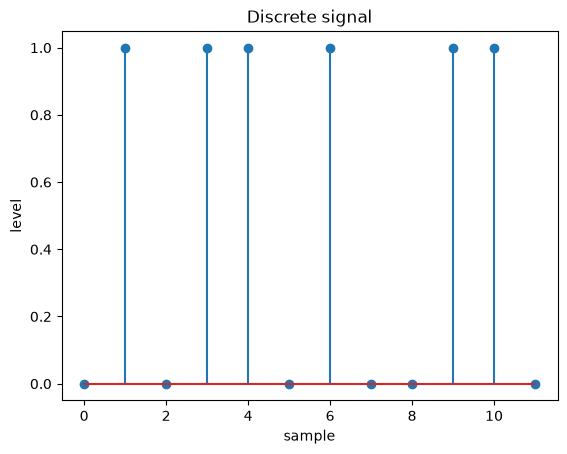

In [7]:
x = np.linspace(0, 2 * np.pi, 200)
mean = np.sin(x)
band = 0.2

fig, ax = plt.subplots()
ax.plot(x, mean, color="tab:blue", label="mean")
ax.fill_between(x, mean - band, mean + band, color="tab:blue", alpha=0.25,
                label="±0.2 band")
ax.set_title("Mean with an uncertainty band")
ax.legend()
plt.show()

n = np.arange(12)
signal = np.array([0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0])

fig, ax = plt.subplots()
ax.stem(n, signal)
ax.set_title("Discrete signal")
ax.set_xlabel("sample")
ax.set_ylabel("level")
plt.show()

## 2. Experiment

Predict the result *before* running each cell.

**Experiment 1:** what do `s`, `alpha`, and `c` do to a scatter plot?

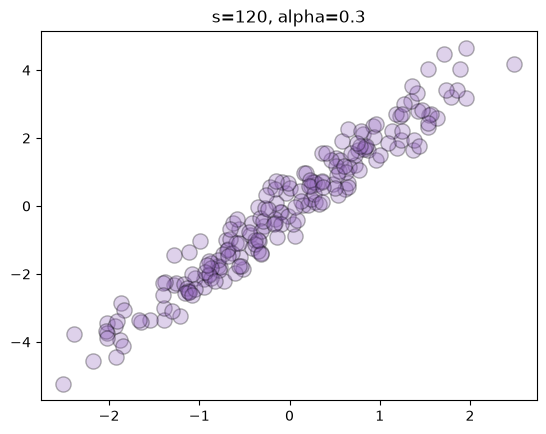

In [8]:
sx = rng.normal(size=200)
sy = 2 * sx + rng.normal(scale=0.5, size=200)

fig, ax = plt.subplots()
ax.scatter(sx, sy, s=120, c="tab:purple", alpha=0.3, edgecolors="black")
ax.set_title("s=120, alpha=0.3")
plt.show()

**Experiment 2:** change the number of histogram bins.

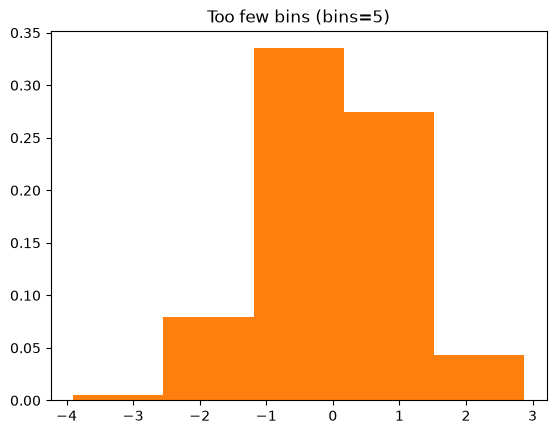

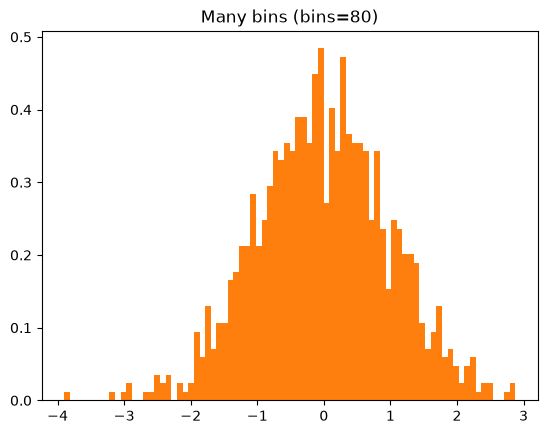

In [9]:
fig, ax = plt.subplots()
ax.hist(samples, bins=5, density=True, color="tab:orange")
ax.set_title("Too few bins (bins=5)")
plt.show()

fig, ax = plt.subplots()
ax.hist(samples, bins=80, density=True, color="tab:orange")
ax.set_title("Many bins (bins=80)")
plt.show()

**Experiment 3:** asymmetric error bars by passing a 2×N array to `yerr`.

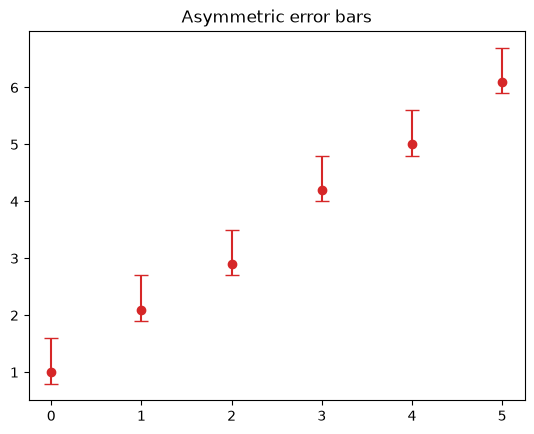

In [10]:
xe = np.arange(6)
ye = np.array([1.0, 2.1, 2.9, 4.2, 5.0, 6.1])
yerr_asym = np.vstack([np.full(6, 0.2), np.full(6, 0.6)])

fig, ax = plt.subplots()
ax.errorbar(xe, ye, yerr=yerr_asym, fmt="o", capsize=5, color="tab:red")
ax.set_title("Asymmetric error bars")
plt.show()

**Experiment 4:** stack two bar series using the `bottom=` argument.

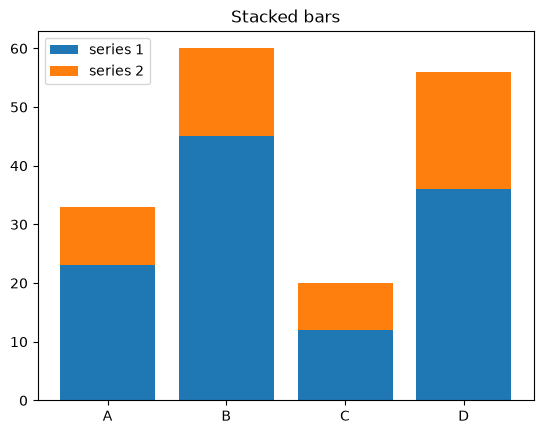

In [11]:
values_b = [10, 15, 8, 20]

fig, ax = plt.subplots()
ax.bar(categories, values, label="series 1", color="tab:blue")
ax.bar(categories, values_b, bottom=values, label="series 2", color="tab:orange")
ax.set_title("Stacked bars")
ax.legend()
plt.show()

**Experiment 5:** `fill_between` can shade between two different curves.

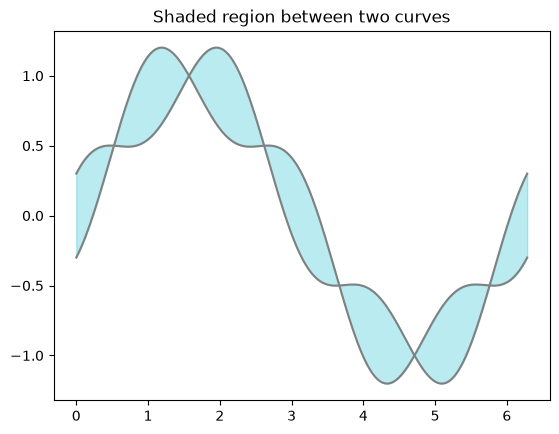

In [12]:
xf = np.linspace(0, 2 * np.pi, 200)
lo = np.sin(xf) - 0.3 * np.cos(3 * xf)
hi = np.sin(xf) + 0.3 * np.cos(3 * xf)

fig, ax = plt.subplots()
ax.plot(xf, lo, color="gray")
ax.plot(xf, hi, color="gray")
ax.fill_between(xf, lo, hi, color="tab:cyan", alpha=0.3)
ax.set_title("Shaded region between two curves")
plt.show()

## 3. Mini Project — Distribution & Comparison

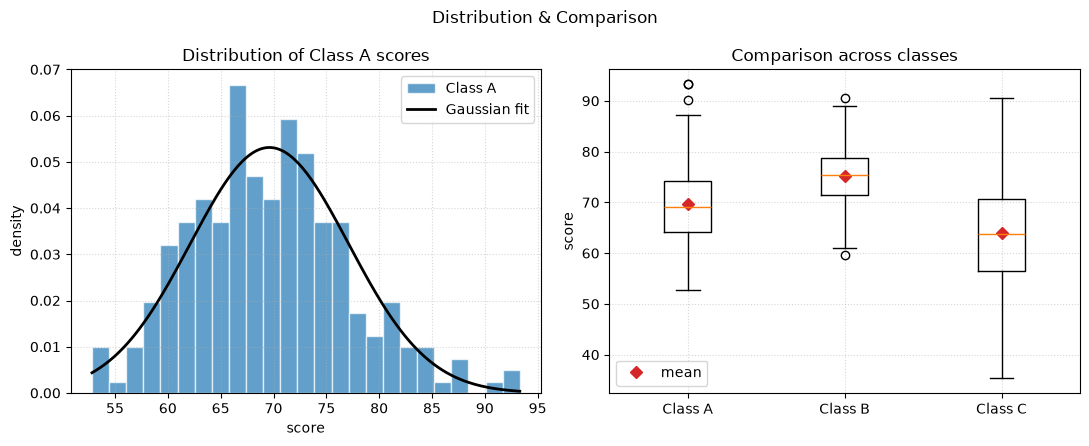

In [13]:
rng = np.random.default_rng(42)
group_a = rng.normal(loc=70, scale=8, size=250)
group_b = rng.normal(loc=75, scale=6, size=250)
group_c = rng.normal(loc=65, scale=10, size=250)
groups = [group_a, group_b, group_c]
names = ["Class A", "Class B", "Class C"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: distribution of one group
ax = axes[0]
ax.hist(group_a, bins=25, density=True, color="tab:blue", alpha=0.7,
        edgecolor="white", label="Class A")
xs = np.linspace(group_a.min(), group_a.max(), 200)
pdf = np.exp(-0.5 * ((xs - group_a.mean()) / group_a.std()) ** 2) / (
    group_a.std() * np.sqrt(2 * np.pi)
)
ax.plot(xs, pdf, color="black", linewidth=2, label="Gaussian fit")
ax.set_title("Distribution of Class A scores")
ax.set_xlabel("score")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)

# Right: comparison across groups
ax = axes[1]
ax.boxplot(groups, tick_labels=names)
means = [g.mean() for g in groups]
ax.plot(range(1, len(groups) + 1), means, "D", color="tab:red", label="mean")
ax.set_title("Comparison across classes")
ax.set_ylabel("score")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Distribution & Comparison")
fig.tight_layout()
fig.savefig("distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()